In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("173 mushrooms.csv")

In [3]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [9]:
df["habitat"].value_counts()

habitat
d    3148
g    2148
p    1144
l     832
u     368
m     292
w     192
Name: count, dtype: int64

## The Data

### Mushroom Hunting: Edible or Poisonous?

Data Source: https://archive.ics.uci.edu/ml/datasets/Mushroom


This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525). Each species is identified as definitely edible, definitely poisonous, or of unknown edibility and not recommended. This latter class was combined with the poisonous one. The Guide clearly states that there is no simple rule for determining the edibility of a mushroom; no rule like ``leaflets three, let it be'' for Poisonous Oak and Ivy.


Attribute Information:

1. cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s
2. cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
3. cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r, pink=p,purple=u,red=e,white=w,yellow=y
4. bruises?: bruises=t,no=f
5. odor: almond=a,anise=l,creosote=c,fishy=y,foul=f, musty=m,none=n,pungent=p,spicy=s
6. gill-attachment: attached=a,descending=d,free=f,notched=n
7. gill-spacing: close=c,crowded=w,distant=d
8. gill-size: broad=b,narrow=n
9. gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e, white=w,yellow=y
10. stalk-shape: enlarging=e,tapering=t
11. stalk-root: bulbous=b,club=c,cup=u,equal=e, rhizomorphs=z,rooted=r,missing=?
12. stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
13. stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
14. stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
15. stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
16. veil-type: partial=p,universal=u
17. veil-color: brown=n,orange=o,white=w,yellow=y
18. ring-number: none=n,one=o,two=t
19. ring-type: cobwebby=c,evanescent=e,flaring=f,large=l, none=n,pendant=p,sheathing=s,zone=z
20. spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r, orange=o,purple=u,white=w,yellow=y
21. population: abundant=a,clustered=c,numerous=n, scattered=s,several=v,solitary=y
22. habitat: grasses=g,leaves=l,meadows=m,paths=p, urban=u,waste=w,woods=d

# Goal

**THIS IS IMPORTANT, THIS IS NOT OUR TYPICAL PREDICTIVE MODEL!**

Our general goal here is to see if we can harness the power of machine learning and boosting to help create not just a predictive model, but a general guideline for features people should look out for when picking mushrooms.

<Axes: xlabel='class', ylabel='count'>

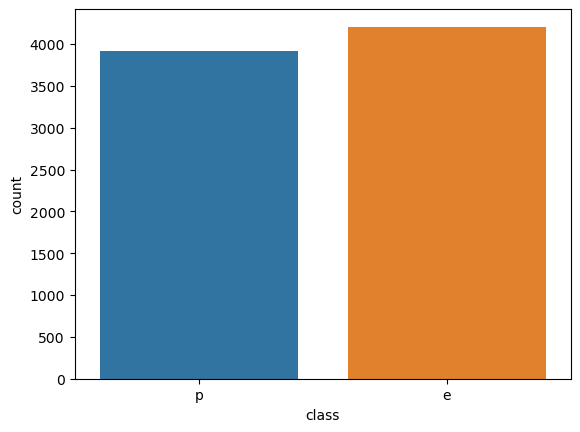

In [11]:
sns.countplot(df,x="class",hue="class")

In [12]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [20]:
 features=df.describe().transpose().sort_values("unique").reset_index()

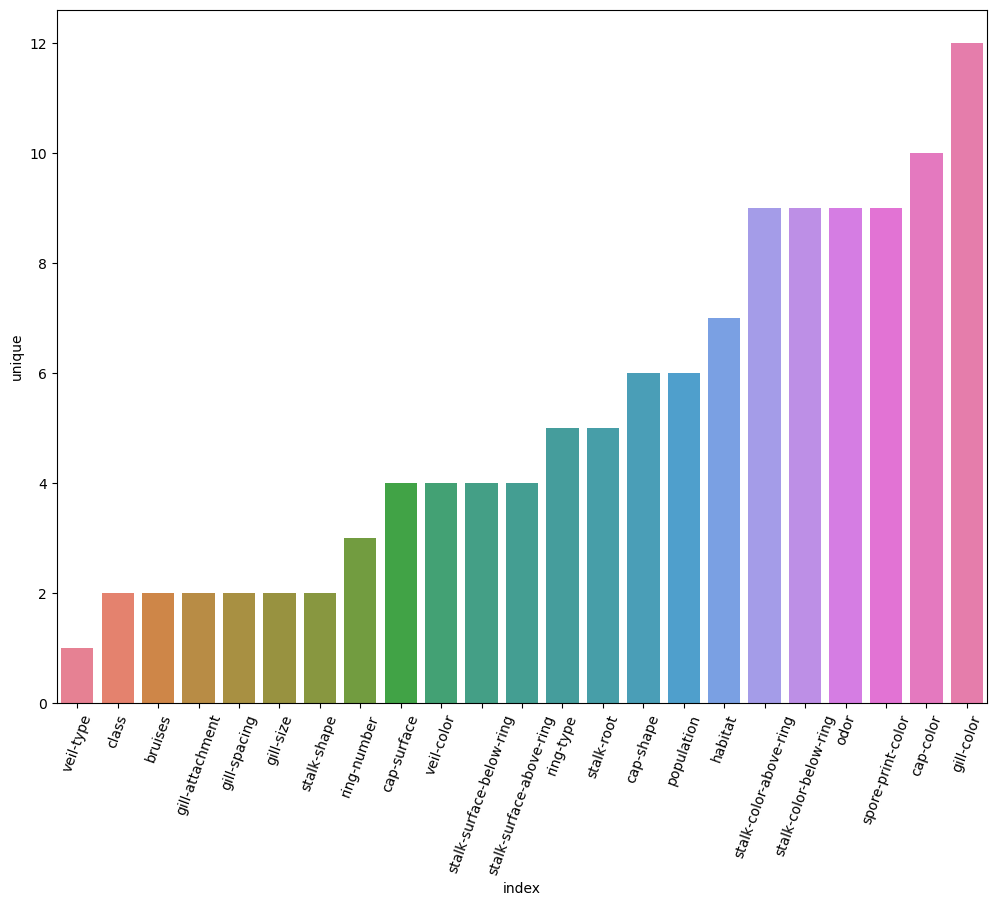

In [32]:
plt.figure(figsize=(12,9))
sns.barplot(features,x="index",y="unique",hue='index')
plt.xticks(rotation=70);

In [46]:
X=df.drop("class",axis=1)
y=df["class"]

In [49]:
from sklearn.preprocessing import OneHotEncoder
encorder=OneHotEncoder()
encorder.fit(X)
X=encorder.transform(X)



In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.15,random_state=101)

In [47]:
# X=pd.get_dummies(X)

In [53]:
from sklearn.ensemble import AdaBoostClassifier

In [54]:
model=AdaBoostClassifier(n_estimators=1)

In [55]:
model.fit(X_train,y_train)

,estimator,None
,n_estimators,1
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [56]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score,confusion_matrix

In [57]:
pred=model.predict(X_test)

In [66]:
pd.DataFrame(classification_report(y_test,pred,output_dict=True))

,e,p,accuracy,macro avg,weighted avg
precision,0.958333,0.811094,0.877769,0.884714,0.890210
recall,0.807634,0.959220,0.877769,0.883427,0.877769
f1-score,0.876553,0.878960,0.877769,0.877757,0.877667
support,655.000000,564.000000,0.877769,1219.000000,1219.000000


In [68]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           e       0.96      0.81      0.88       655
           p       0.81      0.96      0.88       564

    accuracy                           0.88      1219
   macro avg       0.88      0.88      0.88      1219
weighted avg       0.89      0.88      0.88      1219



In [70]:
model.feature_importances_.argmax()

np.int64(54)

In [79]:
error_rates =[]

for n in range(1,96):
    model=AdaBoostClassifier(n_estimators=n)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    error=1-accuracy_score(y_test,y_pred)
    error_rates.append(error)    

In [83]:
error_rates

[0.12223133716160783,
 0.12223133716160783,
 0.08039376538146026,
 0.054963084495488146,
 0.059064807219031956,
 0.040196882690730074,
 0.06398687448728468,
 0.040196882690730074,
 0.06398687448728468,
 0.040196882690730074,
 0.040196882690730074,
 0.03527481542247746,
 0.02789171452009842,
 0.02789171452009842,
 0.02789171452009842,
 0.01312551271534046,
 0.02789171452009842,
 0.02789171452009842,
 0.01312551271534046,
 0.02789171452009842,
 0.02789171452009842,
 0.01312551271534046,
 0.01312551271534046,
 0.01312551271534046,
 0.01312551271534046,
 0.018867924528301883,
 0.01312551271534046,
 0.01312551271534046,
 0.01312551271534046,
 0.01312551271534046,
 0.003281378178835115,
 0.003281378178835115,
 0.003281378178835115,
 0.003281378178835115,
 0.010664479081214151,
 0.003281378178835115,
 0.003281378178835115,
 0.003281378178835115,
 0.003281378178835115,
 0.003281378178835115,
 0.004101722723543921,
 0.003281378178835115,
 0.001640689089417502,
 0.004101722723543921,
 0.00164068

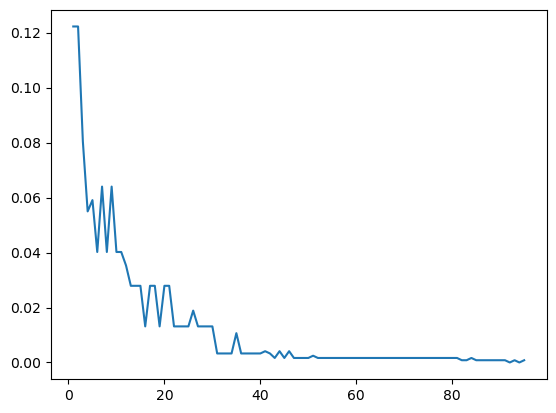

In [82]:
ax=plt.subplot()

ax.plot(range(1,96),error_rates)

In [84]:
model

,estimator,None
,n_estimators,95
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [86]:
model.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.01189619, 0.00837295,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00815341, 0.01062461, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.06492432,
       0.07961084, 0.        , 0.        , 0.05441544, 0.03379141,
       0.07246682, 0.06262426, 0.        , 0.        , 0.06578293,
       0.06241015, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.02253109, 0.01304995, 0.02394505, 0.        , 0.     

In [90]:
# feats = pd.DataFrame(index=X.toarray().columns,data=model.feature_importances,columns="Importance")